# Proyecto Modelos Estadísticos Lineales
#### Pablo Ortega y Juan Sebastián Suescún

## 1) Importar librerías y datos

Cargar librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11

# Modelado: GLM con familia Bernoulli y enlace logit, mas pruebas de diagnostico
import statsmodels.api as sm
from statsmodels.formula.api import logit
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset

# Metricas de clasificacion: tasas, balanceadas, probabilisticas y curvas
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    matthews_corrcoef, cohen_kappa_score, balanced_accuracy_score,
    brier_score_loss, log_loss
)
from sklearn.calibration import calibration_curve

print('Librerías importadas correctamente')

Librerías importadas correctamente


Importar datos

In [2]:
df=pd.read_csv(r"C:\Users\adri_\OneDrive\Documentos\Juan Sebastian\LOS ANDES\8. Octavo semestre\Modelos estadisticos lineales\Proyecto\brain_stroke.csv")

In [3]:
print(df["work_type"].value_counts())

work_type
Private          2860
Self-employed     804
children          673
Govt_job          644
Name: count, dtype: int64


## 2) Preprocesamiento de datos

#### Descripción del Dataset

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4981.0,43.419859,22.662755,0.08,25.00,45.00,61.00,82.00
hypertension,4981.0,0.096165,0.294848,0.00,0.00,0.00,0.00,1.00
heart_disease,4981.0,0.055210,0.228412,0.00,0.00,0.00,0.00,1.00
avg_glucose_level,4981.0,105.943562,45.075373,55.12,77.23,91.85,113.86,271.74
bmi,4981.0,28.498173,6.790464,14.00,23.70,28.10,32.60,48.90
stroke,4981.0,0.049789,0.217531,0.00,0.00,0.00,0.00,1.00


In [5]:
df[["age", "avg_glucose_level", "bmi"]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
age,4981.0,43.42,22.66,0.08,25.00,45.00,61.00,82.00
avg_glucose_level,4981.0,105.94,45.08,55.12,77.23,91.85,113.86,271.74
bmi,4981.0,28.50,6.79,14.00,23.70,28.10,32.60,48.90


### Revisión de desbalance de clases

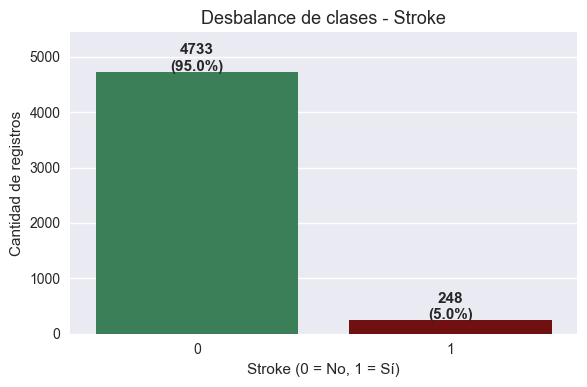

In [6]:
conteo=df["stroke"].value_counts()
class_pct = df["stroke"].value_counts(normalize=True) * 100

# Gráfica
fig, ax = plt.subplots(figsize=(6, 4))

sns.barplot(x=conteo.index.astype(str), y=conteo.values, 
            palette=["seagreen", "maroon"], ax=ax)

# Etiquetas con conteo y porcentaje
for i, (count, pct) in enumerate(zip(conteo.values, class_pct.values)):
    ax.text(i, count + 20, f"{count}\n({pct:.1f}%)", 
            ha="center", fontsize=11, fontweight="bold")

ax.set_title("Desbalance de clases - Stroke", fontsize=13)
ax.set_xlabel("Stroke (0 = No, 1 = Sí)")
ax.set_ylabel("Cantidad de registros")
ax.set_ylim(0, conteo.max() * 1.15)

plt.tight_layout()
plt.show()


### División entre categóricas y numéricas

In [7]:
binary_cols = ["hypertension", "heart_disease", "stroke"]
df[binary_cols] = df[binary_cols].astype("object")

In [8]:
df_num = df.select_dtypes(include=["int64", "float64"])
df_num.head()

,age,avg_glucose_level,bmi
0,67.0,228.69,36.6
1,80.0,105.92,32.5
2,49.0,171.23,34.4
3,79.0,174.12,24.0
4,81.0,186.21,29.0


In [9]:
df_cat = df.select_dtypes(include=["object"])
df_cat.drop(columns=["stroke"], inplace=True)
df_cat.head()

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status
0,Male,0,1,Yes,Private,Urban,formerly smoked
1,Male,0,1,Yes,Private,Rural,never smoked
2,Female,0,0,Yes,Private,Urban,smokes
3,Female,1,0,Yes,Self-employed,Rural,never smoked
4,Male,0,0,Yes,Private,Urban,formerly smoked


## 3) Análisis exploratorio de datos

#### Revisión de faltantes 

In [10]:
print('Valores faltantes por variable:')
print(df.isnull().sum())
print(f'\nTotal de valores faltantes: {df.isnull().sum().sum()}')

Valores faltantes por variable:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Total de valores faltantes: 0


### 3.1) Comportamiento y relación entre predictores

#### Variables numéricas

Distribución de las variables numéricas

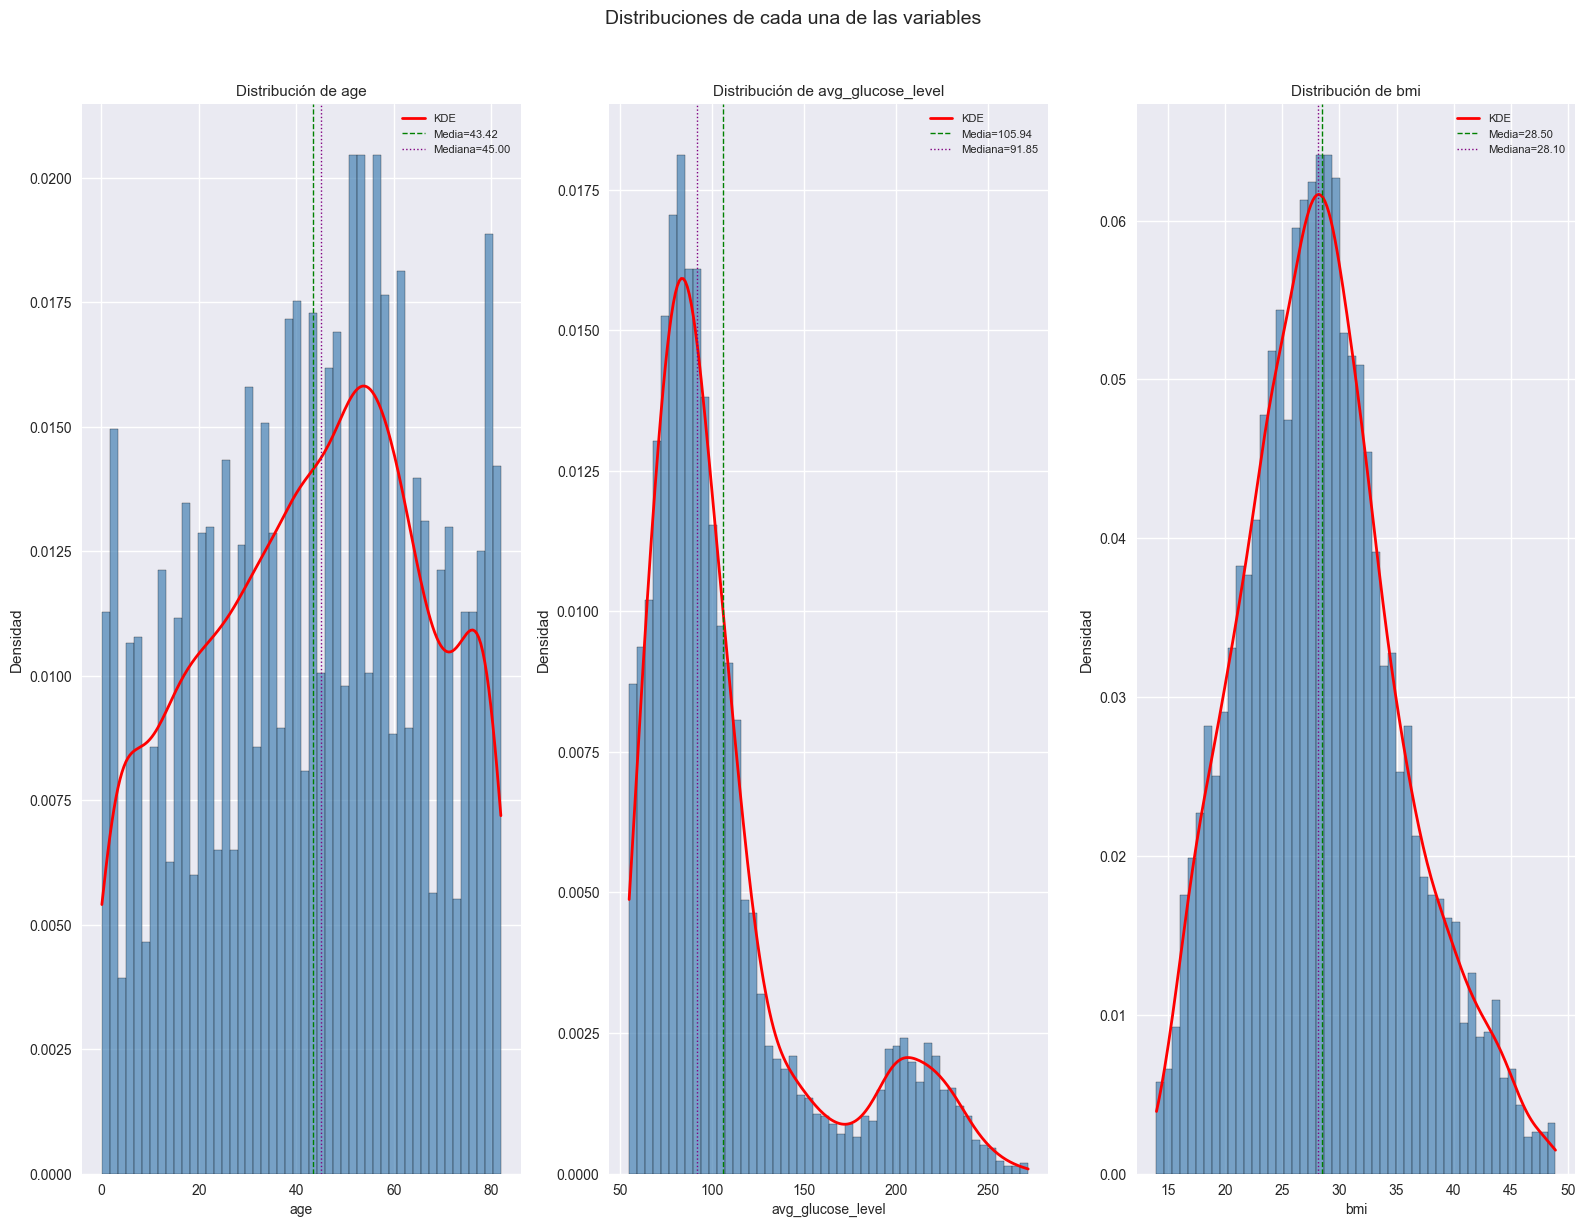

Observaciones sobre las distribuciones:
  age            : sesgo = -0.144 → simétrica
  avg_glucose_level: sesgo = +1.588 → sesgada a la derecha
  bmi            : sesgo = +0.372 → simétrica


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 12))

for i, var in enumerate(df_num.columns):
    ax = axes[i]  # ← ahora sí funciona con 2 filas
    ax.hist(df_num[var], bins=50, edgecolor='black', alpha=0.7,
            color='steelblue', density=True)

    from scipy.stats import gaussian_kde
    data = df_num[var].dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

    mu = data.mean()
    med = data.median()
    ax.axvline(mu, color='green', linestyle='--', linewidth=1, label=f'Media={mu:.2f}')
    ax.axvline(med, color='purple', linestyle=':', linewidth=1, label=f'Mediana={med:.2f}')
    ax.set_title(f'Distribución de {var}', fontsize=11)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)

plt.suptitle('Distribuciones de cada una de las variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('Observaciones sobre las distribuciones:')
for var in df_num.columns:
    sk = df_num[var].skew()
    tipo = 'simétrica' if abs(sk) < 0.5 else ('sesgada a la derecha' if sk > 0 else 'sesgada a la izquierda')
    print(f'  {var:15s}: sesgo = {sk:+.3f} → {tipo}')

 Aplicar logaritmo al nivel de glucosa y al BMI

In [12]:
df["log_glucose"] = np.log(df["avg_glucose_level"])
df["log_bmi"] = np.log(df["bmi"])
df["log_age"] = np.log(df["age"])

df_num["log_glucose"] = np.log(df_num["avg_glucose_level"])
df_num["log_bmi"] = np.log(df_num["bmi"])
df_num["log_age"] = np.log(df_num["age"])


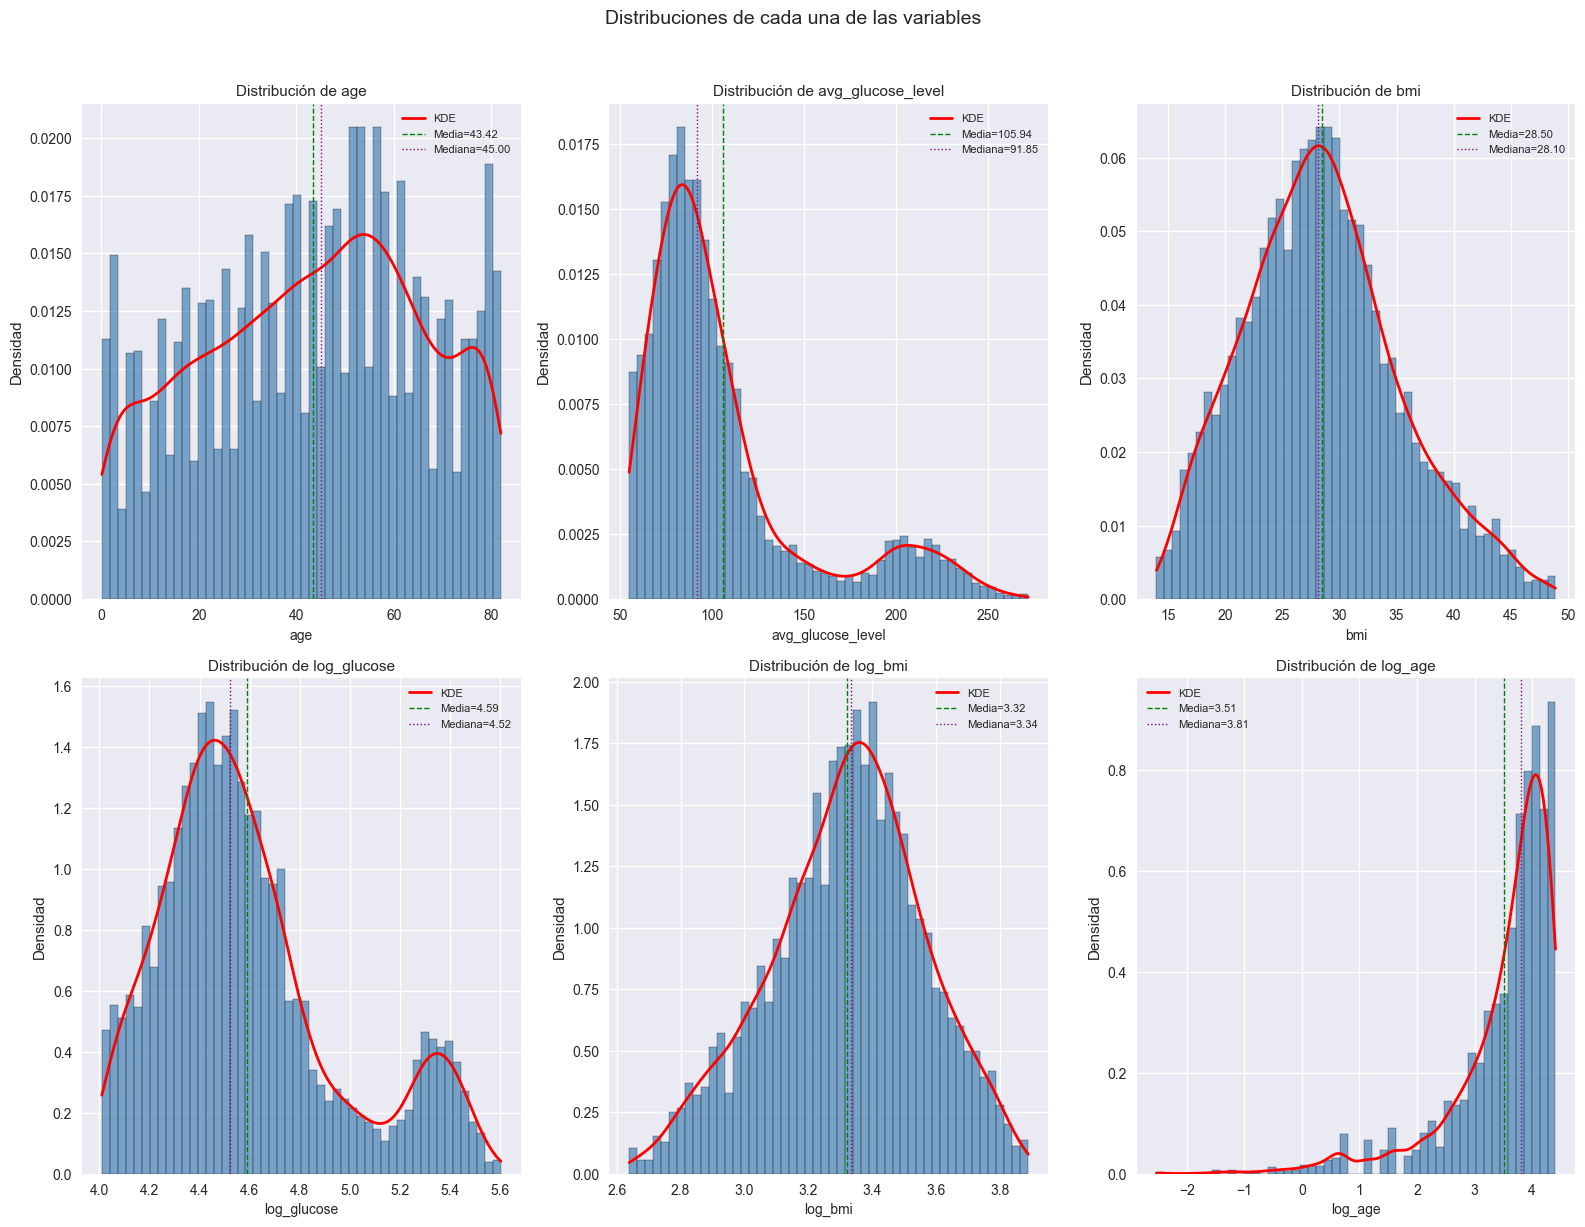

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 12))

for i, var in enumerate(df_num.columns):
    ax = axes[i // 3, i % 3]  # ← ahora sí funciona con 2 filas
    ax.hist(df_num[var], bins=50, edgecolor='black', alpha=0.7,
            color='steelblue', density=True)

    from scipy.stats import gaussian_kde
    data = df_num[var].dropna()
    kde = gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')

    mu = data.mean()
    med = data.median()
    ax.axvline(mu, color='green', linestyle='--', linewidth=1, label=f'Media={mu:.2f}')
    ax.axvline(med, color='purple', linestyle=':', linewidth=1, label=f'Mediana={med:.2f}')
    ax.set_title(f'Distribución de {var}', fontsize=11)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)


plt.suptitle('Distribuciones de cada una de las variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Quitar logaritmos

In [14]:
df_num.drop(columns=["log_glucose", "log_bmi","log_age"], inplace=True)
df.drop(columns=["log_glucose", "log_bmi","log_age"], inplace=True)

Detección de outliers

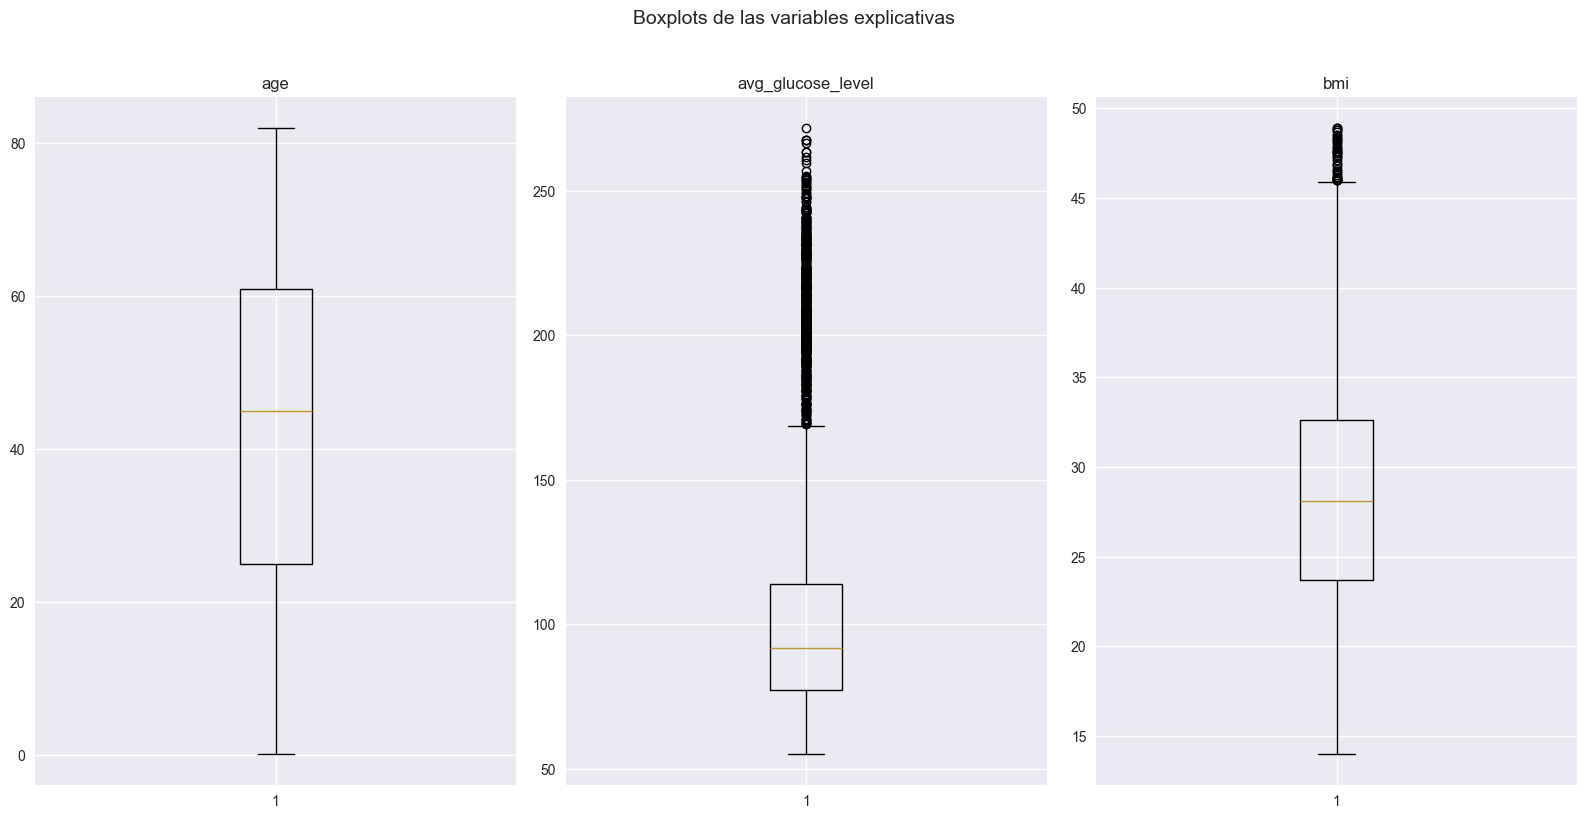

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 8), squeeze=False)
variables = [c for c in df_num.columns]
for i, var in enumerate(variables):
    ax = axes[0,i]  # fila 0, columna i
    ax.boxplot(df_num[var], vert=True)
    ax.set_title(var)

plt.suptitle('Boxplots de las variables explicativas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Pair plot de las variables

Generando pairplot (puede tomar unos segundos)...


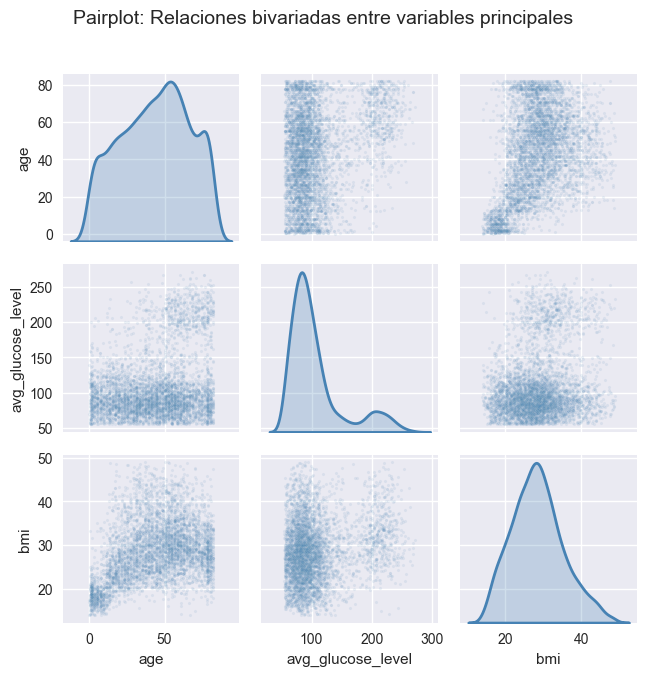

In [16]:
vars_pairplot = df_num.columns.tolist()
print('Generando pairplot (puede tomar unos segundos)...')
g = sns.pairplot(df[vars_pairplot], 
                 diag_kind='kde',
                 plot_kws={'alpha': 0.1, 's': 5, 'color': 'steelblue'},
                 diag_kws={'color': 'steelblue', 'linewidth': 2},
                 height=2.2, aspect=1)
g.figure.suptitle('Pairplot: Relaciones bivariadas entre variables principales', 
                   fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Correlaciones

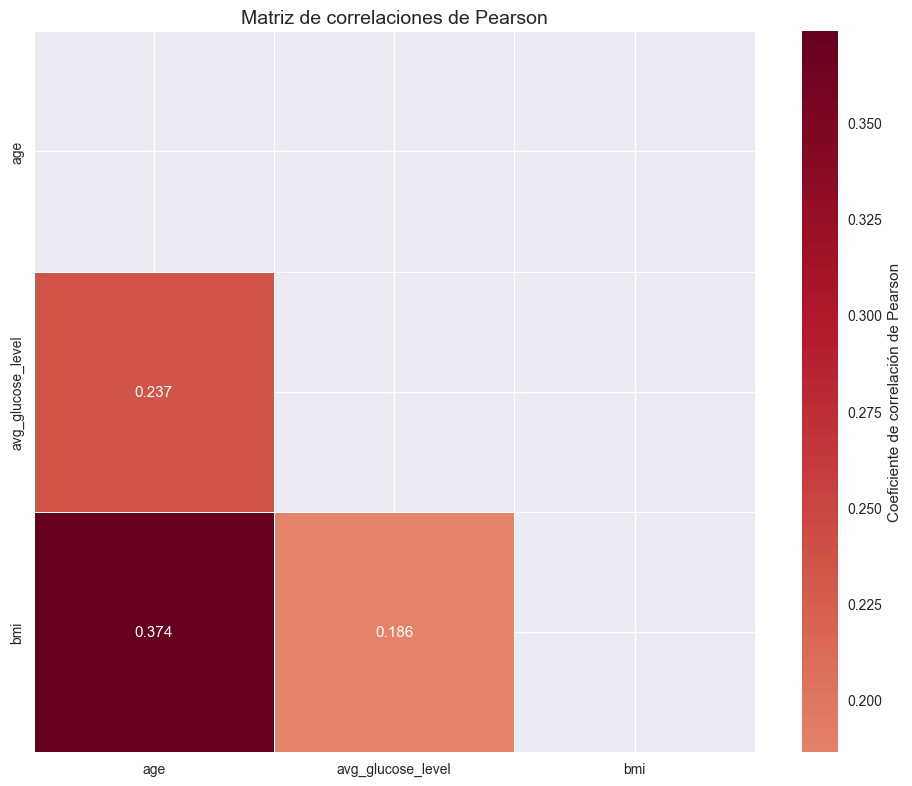

In [17]:
vars_corr = df_num.columns.tolist()

corr_matrix = df[vars_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Coeficiente de correlación de Pearson'})
ax.set_title('Matriz de correlaciones de Pearson', fontsize=14)
plt.tight_layout()
plt.show()


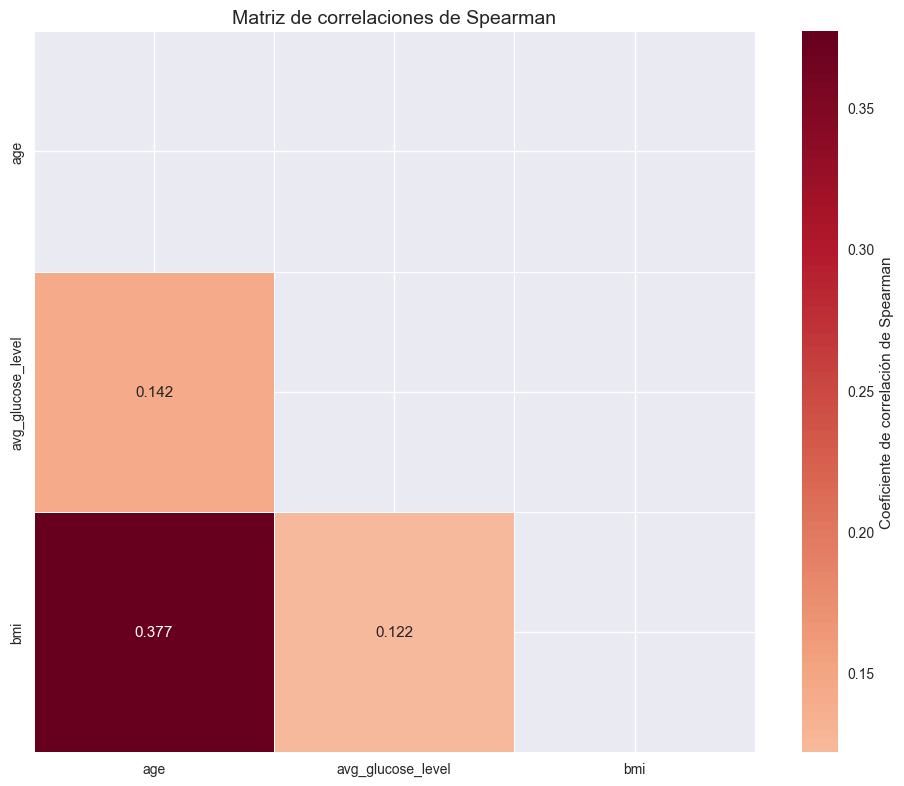

In [18]:


vars_corr = df_num.columns.tolist()

corr_matrix = df[vars_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Coeficiente de correlación de Spearman'})
ax.set_title('Matriz de correlaciones de Spearman', fontsize=14)
plt.tight_layout()
plt.show()


#### Variables categóricas

Distribución de las variables

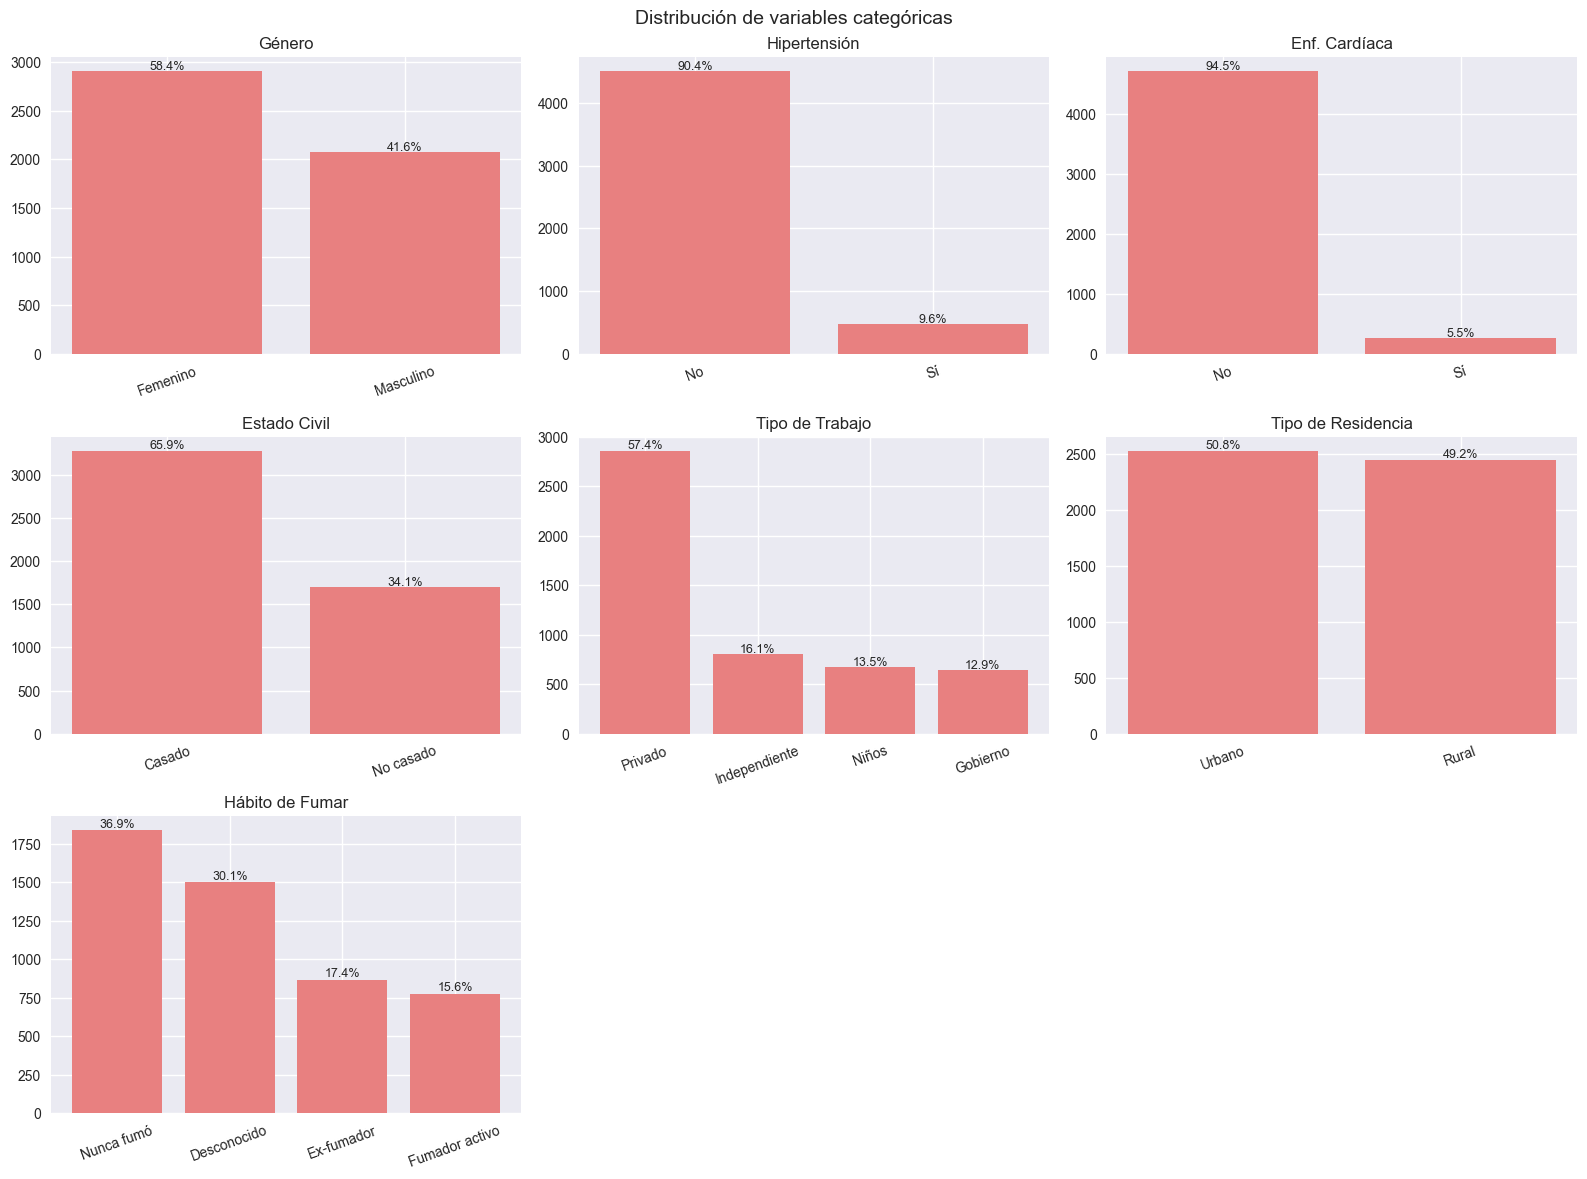

In [19]:
etiquetas = {
    "gender":         ("Género",           {"Female": "Femenino", "Male": "Masculino"}),
    "hypertension":   ("Hipertensión",      {0: "No", 1: "Sí"}),
    "heart_disease":  ("Enf. Cardíaca",     {0: "No", 1: "Sí"}),
    "ever_married":   ("Estado Civil",      {"Yes": "Casado", "No": "No casado"}),
    "work_type":      ("Tipo de Trabajo",   {"Private": "Privado", "Self-employed": "Independiente",
                                             "Govt_job": "Gobierno", "children": "Niños"}),
    "Residence_type": ("Tipo de Residencia",  {"Urban": "Urbano", "Rural": "Rural"}),
    "smoking_status": ("Hábito de Fumar",   {"formerly smoked": "Ex-fumador",
                                             "never smoked": "Nunca fumó",
                                             "smokes": "Fumador activo",
                                             "Unknown": "Desconocido"})
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Distribución de variables categóricas", fontsize=14)

for ax, (col, (titulo, mapa)) in zip(axes.flatten(), etiquetas.items()):
    temp = df[col].map(mapa) if mapa else df[col]
    conteos = temp.value_counts()
    proporciones = conteos / conteos.sum() * 100
    ax.bar(conteos.index, conteos.values, color="#E88080")
    for i, (v, p) in enumerate(zip(conteos.values, proporciones.values)):
        ax.text(i, v + 20, f"{p:.1f}%", ha="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

Relación entre las variables categóricas

In [20]:
pd.crosstab(
    df['smoking_status'],
    df['hypertension'],
    normalize='index'
) * 100


hypertension,0,1
smoking_status,,
Unknown,96.666667,3.333333
formerly smoked,86.735871,13.264129
never smoked,87.867247,12.132753
smokes,88.273196,11.726804


In [21]:
pd.crosstab(
    df['smoking_status'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
smoking_status,,
Unknown,96.800000,3.200000
formerly smoked,91.118800,8.881200
never smoked,95.157780,4.842220
smokes,92.139175,7.860825


In [22]:
pd.crosstab(
    df['hypertension'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
hypertension,,
0,95.313194,4.686806
1,86.638831,13.361169


In [23]:
pd.crosstab(
    df['gender'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
gender,,
Female,96.147231,3.852769
Male,92.140791,7.859209


In [24]:
pd.crosstab(
    df['gender'],
    df['smoking_status'],
    normalize='index'
) * 100

smoking_status,Unknown,formerly smoked,never smoked,smokes
gender,,,,
Female,27.794978,15.961472,41.073271,15.170279
Male,33.365477,19.431051,31.051109,16.152363


In [25]:
pd.crosstab(
    df['gender'],
    df['hypertension'],
    normalize='index'
) * 100

hypertension,0,1
gender,,
Female,90.918473,9.081527
Male,89.633558,10.366442


In [26]:
pd.crosstab(
    df['ever_married'],
    df['heart_disease'],
    normalize='index'
) * 100

heart_disease,0,1
ever_married,,
No,98.118754,1.881246
Yes,92.591463,7.408537


#### Relación entre numéricas y categóricas

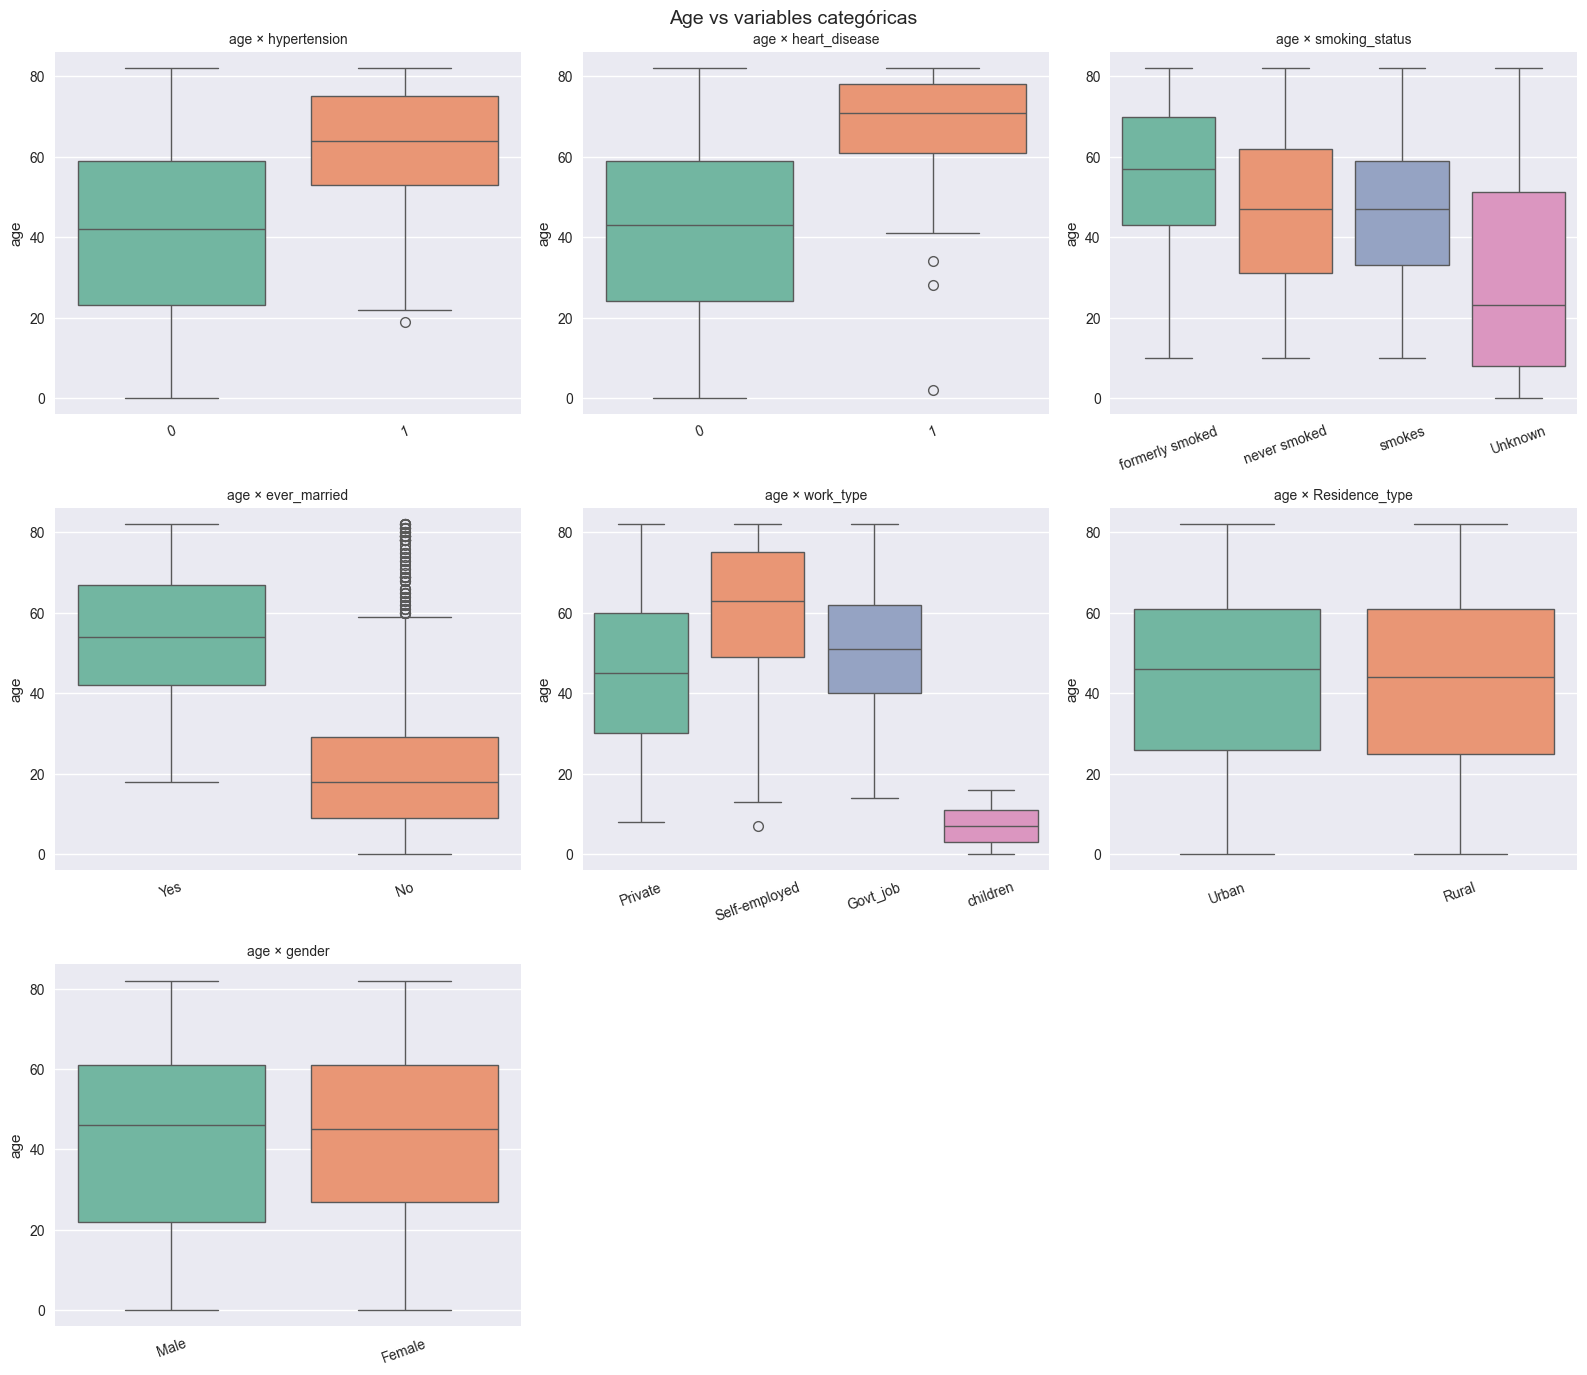

In [27]:
combos_age = [
    ("age", "hypertension"),
    ("age", "heart_disease"),
    ("age", "smoking_status"),
    ("age", "ever_married"),
    ("age", "work_type"),
    ("age", "Residence_type"),
    ("age", "gender"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Age vs variables categóricas", fontsize=14)

for ax, (num, cat) in zip(axes.flatten(), combos_age):
    sns.boxplot(data=df, x=cat, y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × {cat}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

# Ocultar subplots sobrantes
axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

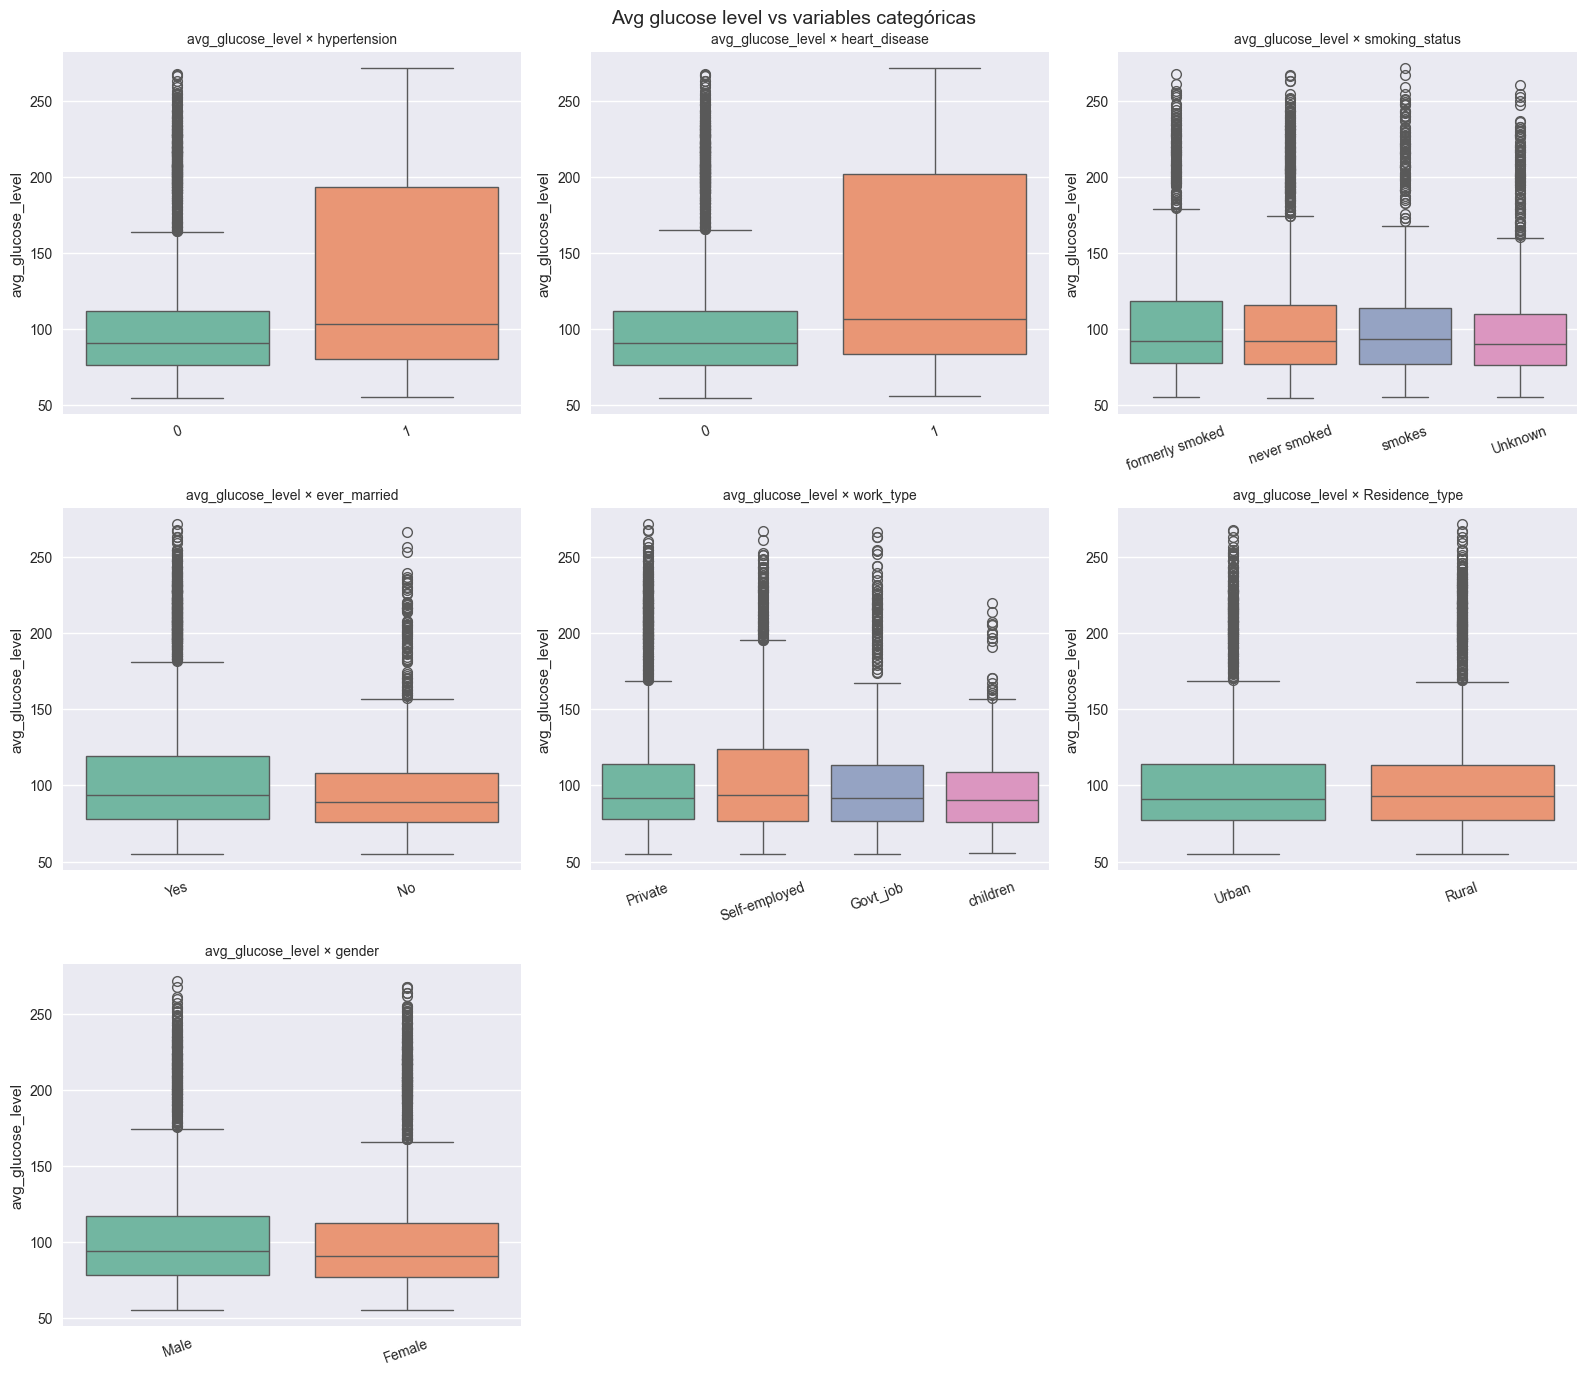

In [28]:
combos_glucose = [
    ("avg_glucose_level", "hypertension"),
    ("avg_glucose_level", "heart_disease"),
    ("avg_glucose_level", "smoking_status"),
    ("avg_glucose_level", "ever_married"),
    ("avg_glucose_level", "work_type"),
    ("avg_glucose_level", "Residence_type"),
    ("avg_glucose_level", "gender"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("Avg glucose level vs variables categóricas", fontsize=14)

for ax, (num, cat) in zip(axes.flatten(), combos_glucose):
    sns.boxplot(data=df, x=cat, y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × {cat}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()


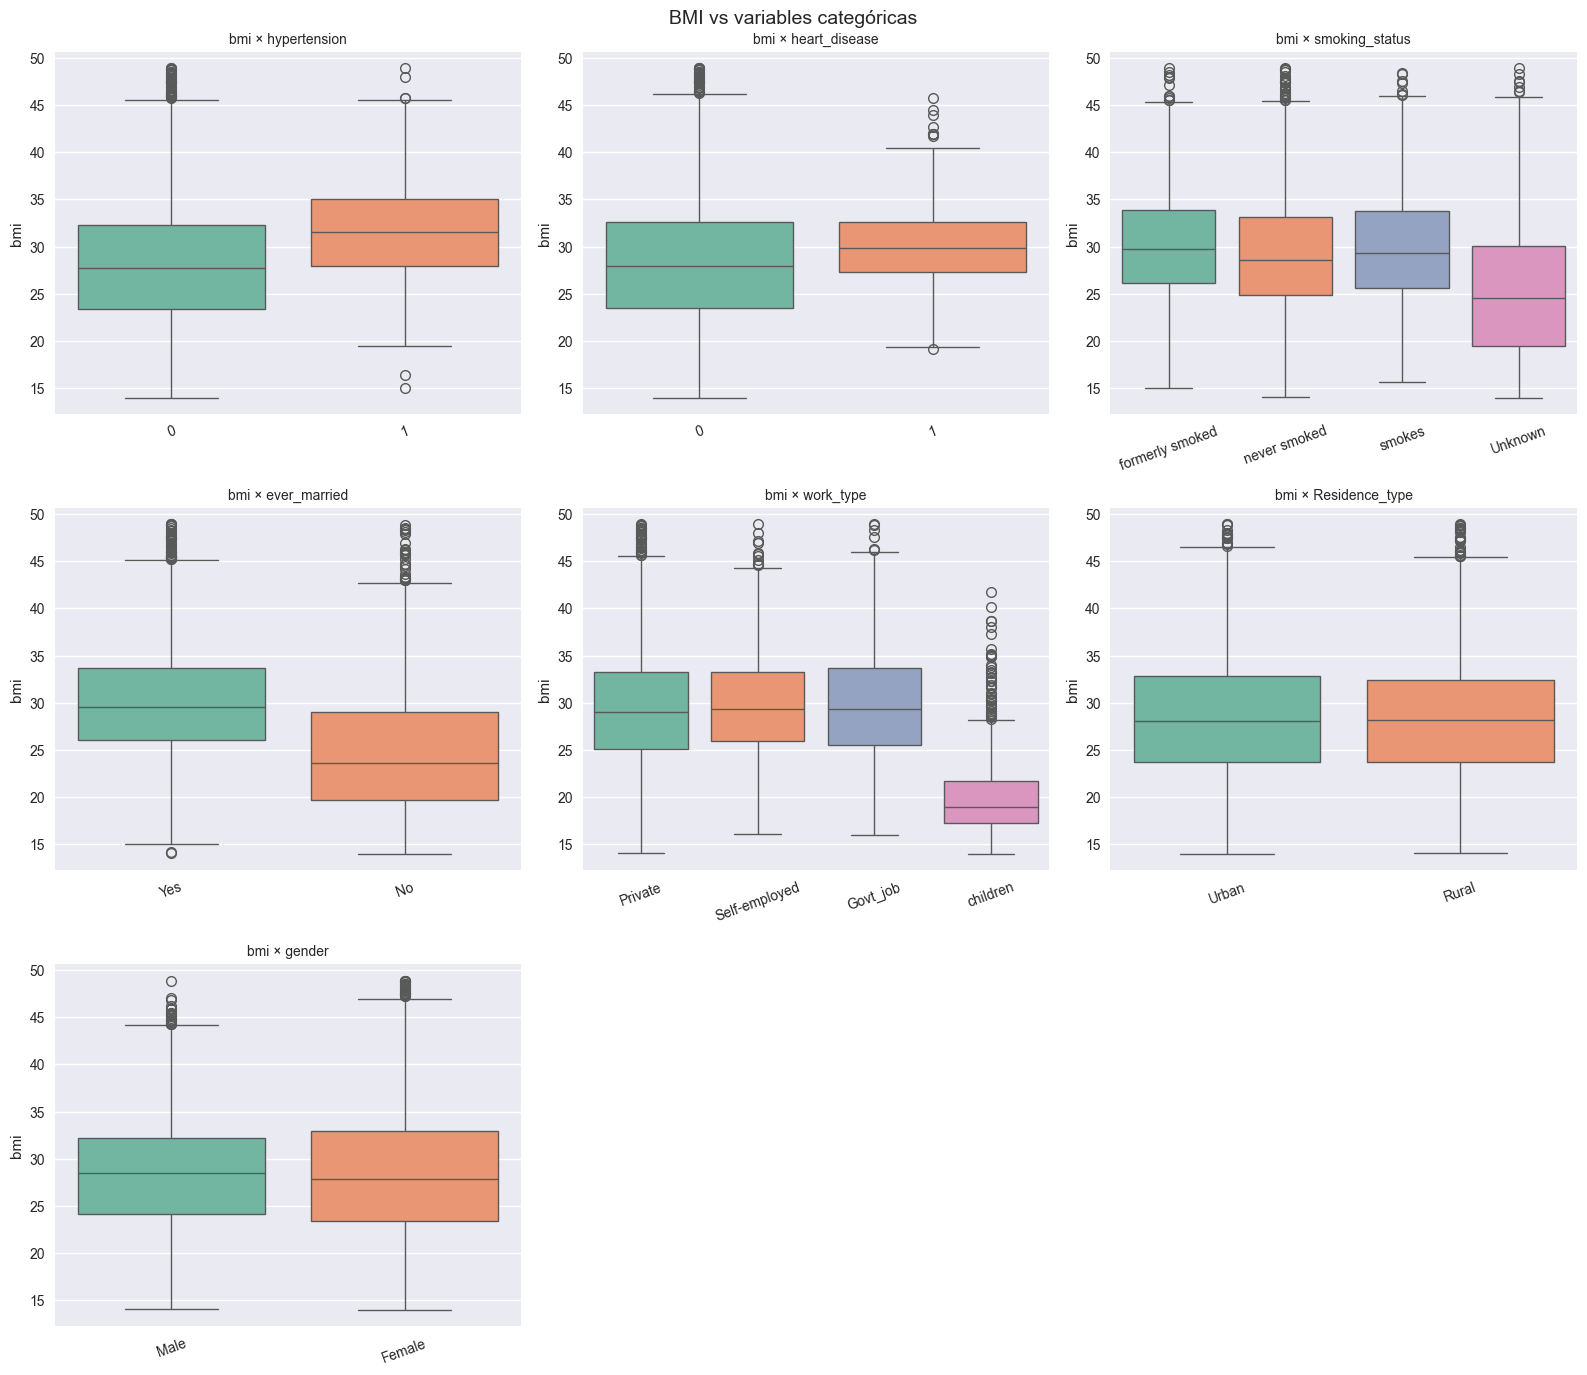

In [29]:
combos_bmi = [
    ("bmi", "hypertension"),
    ("bmi", "heart_disease"),
    ("bmi", "smoking_status"),
    ("bmi", "ever_married"),
    ("bmi", "work_type"),
    ("bmi", "Residence_type"),
    ("bmi", "gender"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle("BMI vs variables categóricas", fontsize=14)

for ax, (num, cat) in zip(axes.flatten(), combos_bmi):
    sns.boxplot(data=df, x=cat, y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × {cat}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)

axes[2][1].set_visible(False)
axes[2][2].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
import itertools

categoricas = ["gender", "hypertension", "heart_disease", 
               "ever_married", "work_type", "Residence_type", "smoking_status"]

pares = list(itertools.combinations(categoricas, 2))

for var1, var2 in pares:
    print(f"--- {var1} × {var2} ---")
    tabla = pd.crosstab(df[var1], df[var2], normalize="index").mul(100).round(1)
    print(tabla)
    print()

--- gender × hypertension ---
hypertension     0     1
gender                  
Female        90.9   9.1
Male          89.6  10.4

--- gender × heart_disease ---
heart_disease     0    1
gender                  
Female         96.1  3.9
Male           92.1  7.9

--- gender × ever_married ---
ever_married    No   Yes
gender                  
Female        33.0  67.0
Male          35.8  64.2

--- gender × work_type ---
work_type  Govt_job  Private  Self-employed  children
gender                                               
Female         13.4     58.6           17.1      10.9
Male           12.2     55.7           14.9      17.2

--- gender × Residence_type ---
Residence_type  Rural  Urban
gender                      
Female           49.0   51.0
Male             49.4   50.6

--- gender × smoking_status ---
smoking_status  Unknown  formerly smoked  never smoked  smokes
gender                                                        
Female             27.8             16.0          41.1 

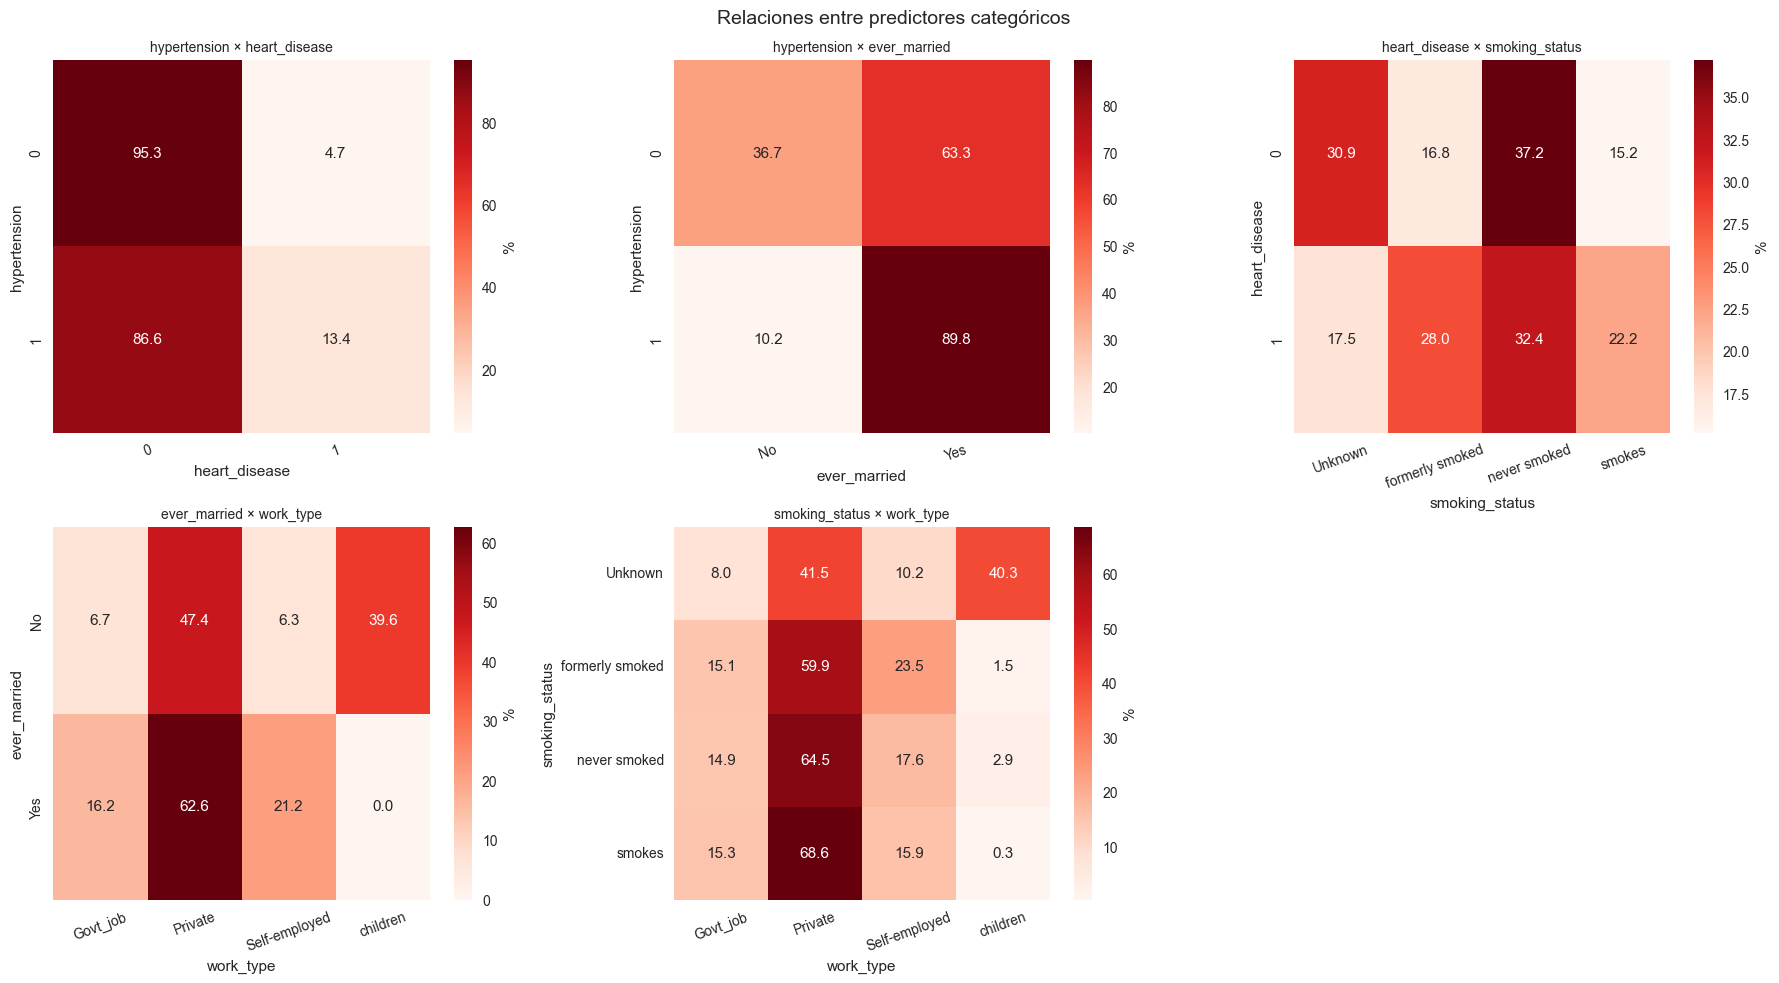

In [31]:
pares_relevantes = [
    ("hypertension", "heart_disease"),
    ("hypertension", "ever_married"),
    ("heart_disease", "smoking_status"),
    ("ever_married", "work_type"),
    ("smoking_status","work_type"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Relaciones entre predictores categóricos", fontsize=14)

for ax, (var1, var2) in zip(axes.flatten(), pares_relevantes):
    tabla = pd.crosstab(df[var1], df[var2], normalize="index").mul(100).round(1)
    sns.heatmap(tabla, annot=True, fmt=".1f", cmap="Reds", ax=ax,
                cbar_kws={"label": "%"})
    ax.set_title(f"{var1} × {var2}", fontsize=10)
    ax.tick_params(axis='x', rotation=20)

axes[1][2].set_visible(False)
plt.tight_layout()
plt.show()

### 3.2) Relación de los predictores con la variable de interés

#### Variables numéricas

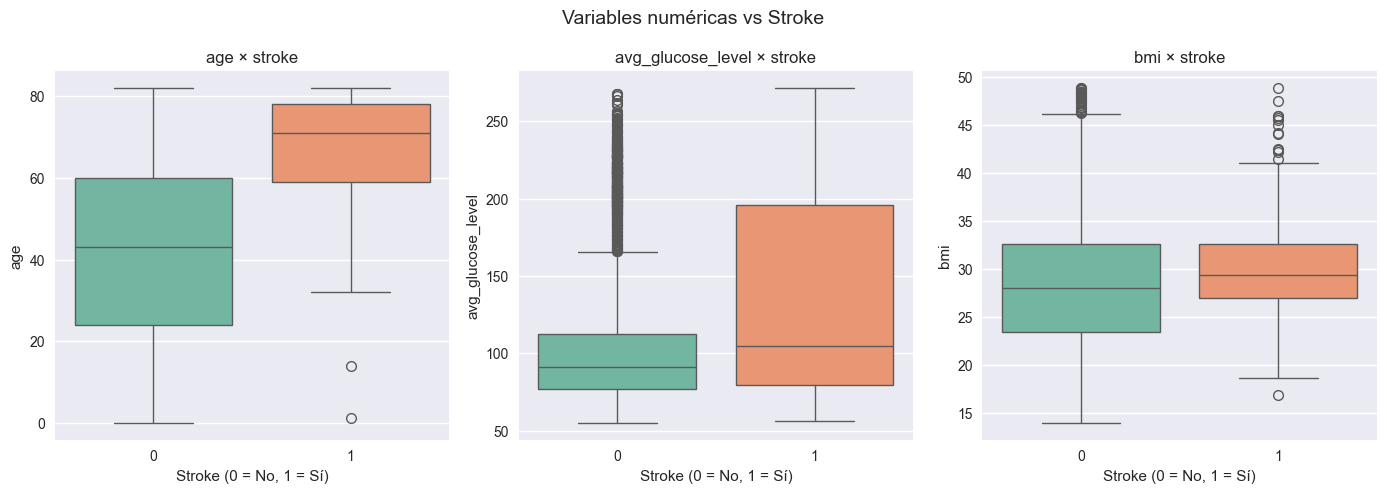

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Variables numéricas vs Stroke", fontsize=14)


for ax, num in zip(axes, df_num.columns.tolist()):
    sns.boxplot(data=df, x="stroke", y=num, ax=ax, palette="Set2")
    ax.set_title(f"{num} × stroke")
    ax.set_xlabel("Stroke (0 = No, 1 = Sí)")

plt.tight_layout()
plt.show()

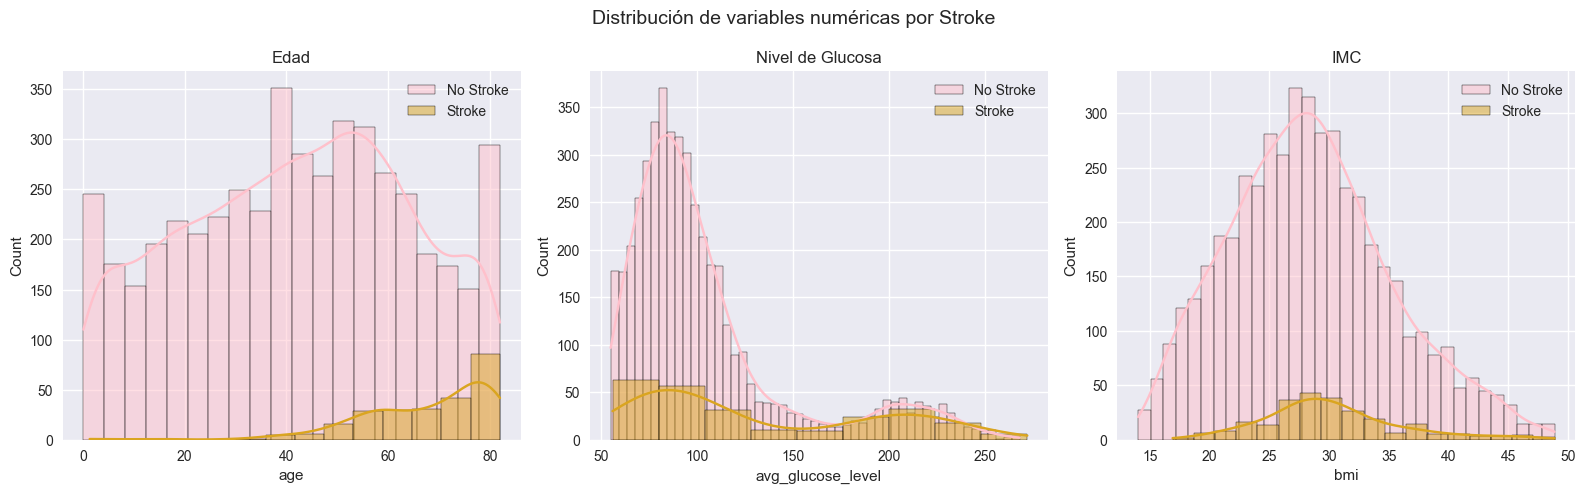

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribución de variables numéricas por Stroke", fontsize=14)

vars_num = [("age", "Edad"), ("avg_glucose_level", "Nivel de Glucosa"), ("bmi", "IMC")]

for ax, (var, titulo) in zip(axes, vars_num):
    for stroke_val, color, label in [(0, "pink", "No Stroke"), (1, "goldenrod", "Stroke")]:
        subset = df[df["stroke"] == stroke_val][var]
        sns.histplot(subset, ax=ax, color=color, label=label, kde=True, alpha=0.5)
    ax.set_title(titulo)
    ax.set_xlabel(var)
    ax.legend()

plt.tight_layout()
plt.show()

#### Variables categóricas

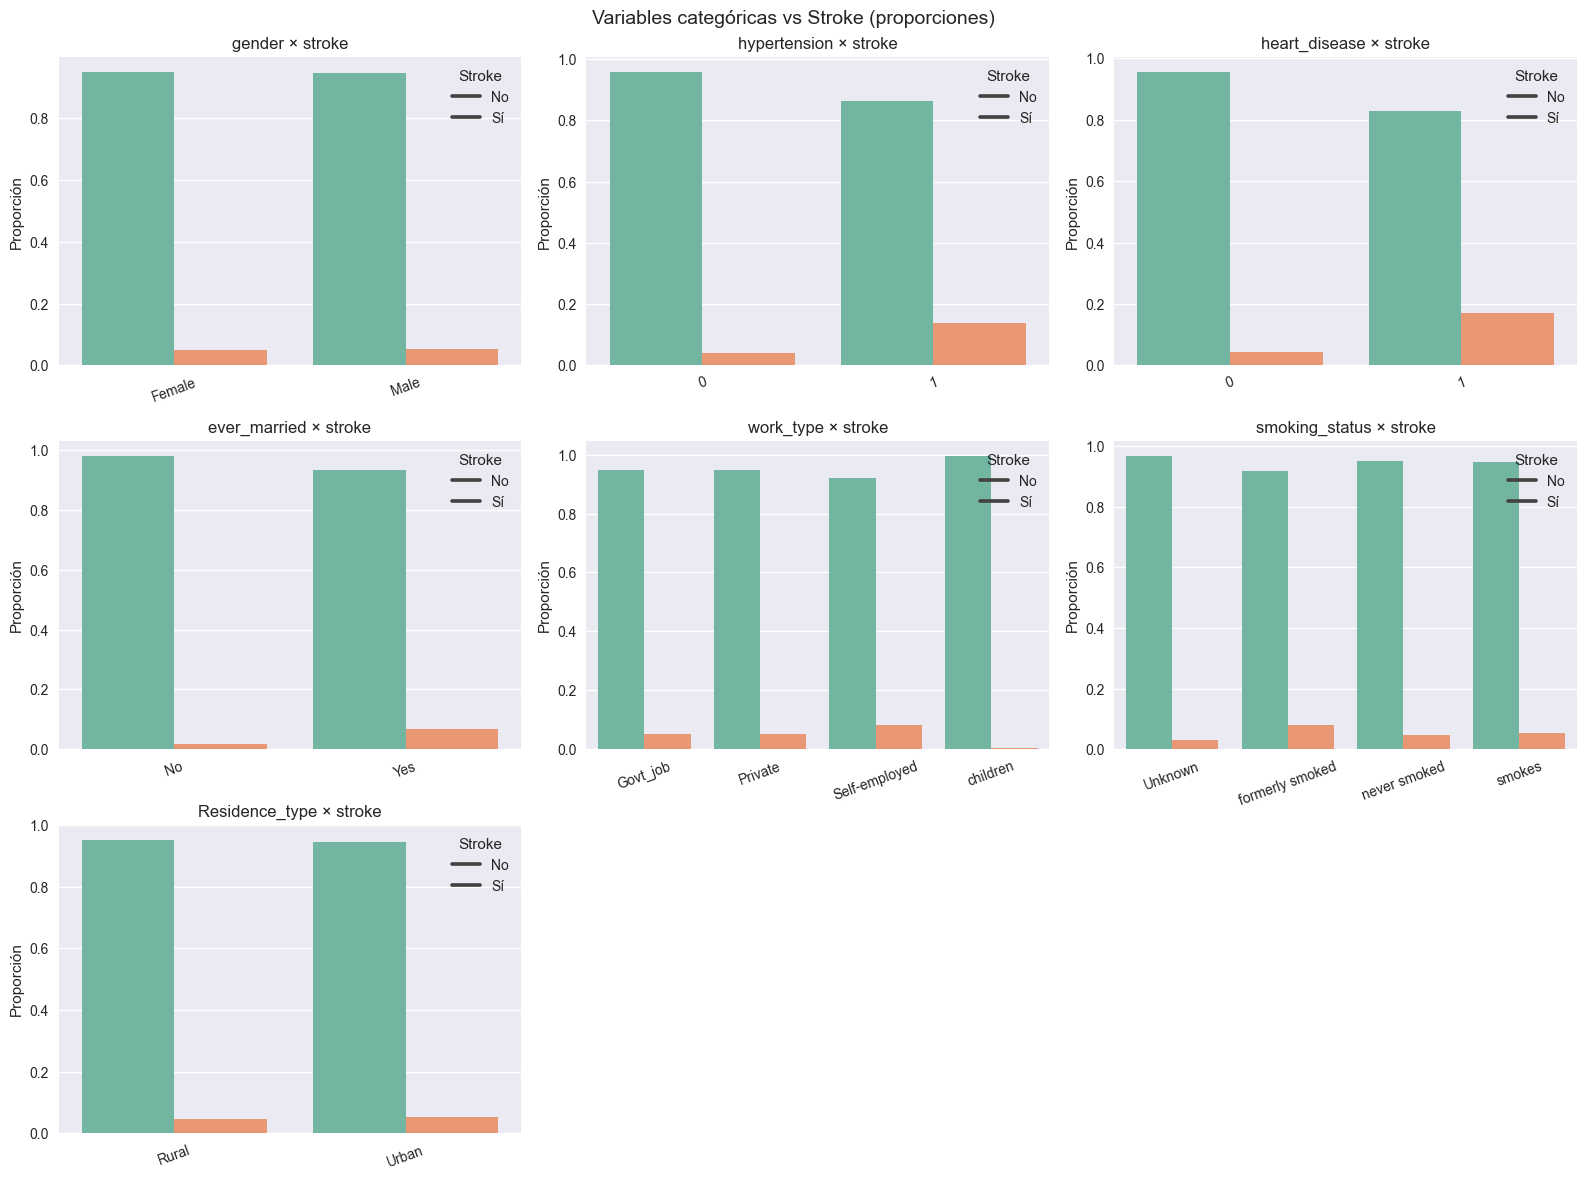

In [34]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Variables categóricas vs Stroke (proporciones)", fontsize=14)

categoricas = ["gender", "hypertension", "heart_disease", 
               "ever_married", "work_type", "smoking_status", "Residence_type"]

for ax, cat in zip(axes.flatten(), categoricas):
    prop = (df.groupby(cat)["stroke"]
              .value_counts(normalize=True)
              .rename("proporcion")
              .reset_index())
    sns.barplot(data=prop, x=cat, y="proporcion", hue="stroke", 
                ax=ax, palette="Set2")
    ax.set_title(f"{cat} × stroke")
    ax.set_xlabel("")
    ax.set_ylabel("Proporción")
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title="Stroke", labels=["No", "Sí"])

axes[2][2].set_visible(False)
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()  

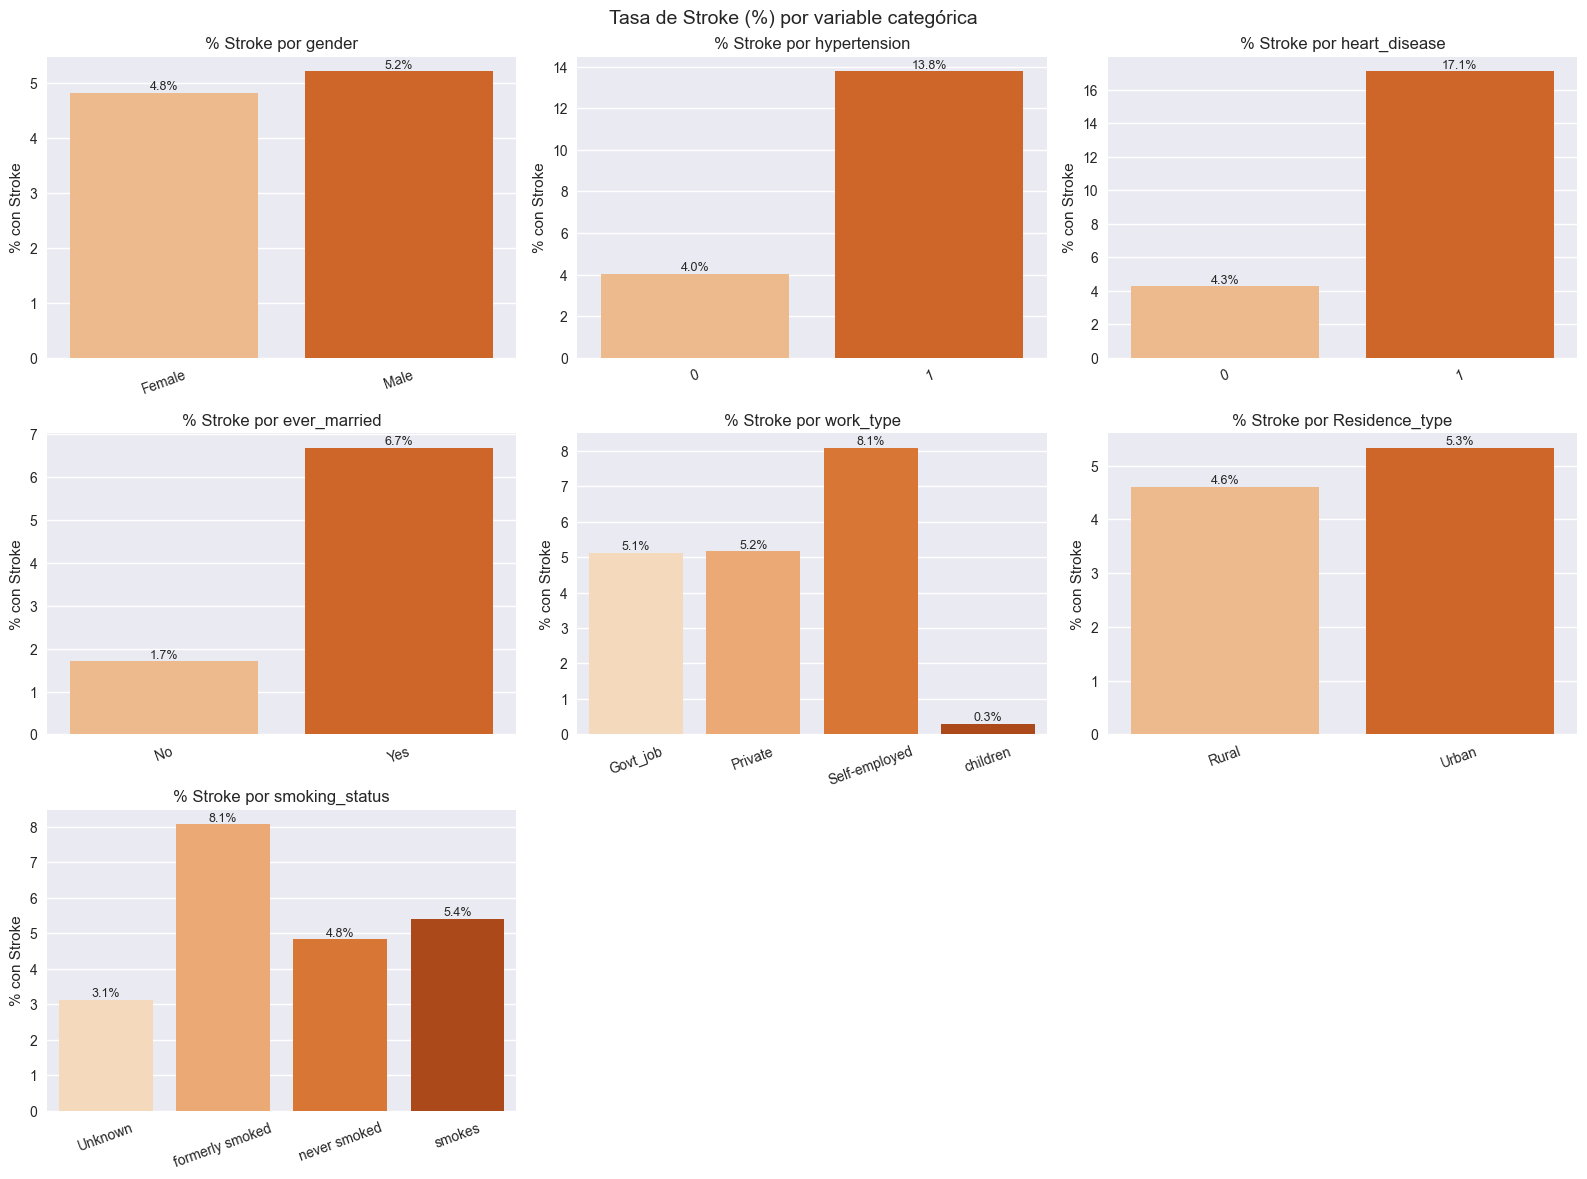

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Tasa de Stroke (%) por variable categórica", fontsize=14)
df['stroke'] = df['stroke'].astype(int)
for ax, cat in zip(axes.flatten(), df_cat.columns.tolist()):
    tasas = df.groupby(cat)["stroke"].mean().mul(100).round(2).reset_index()
    tasas.columns = [cat, "tasa"]
    sns.barplot(data=tasas, x=cat, y="tasa", ax=ax, palette="Oranges")
    ax.set_title(f"% Stroke por {cat}")
    ax.set_xlabel("")
    ax.set_ylabel("% con Stroke")
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", 
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis='x', rotation=20)

axes[2][2].set_visible(False)
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

## 4) Balanceo de clases

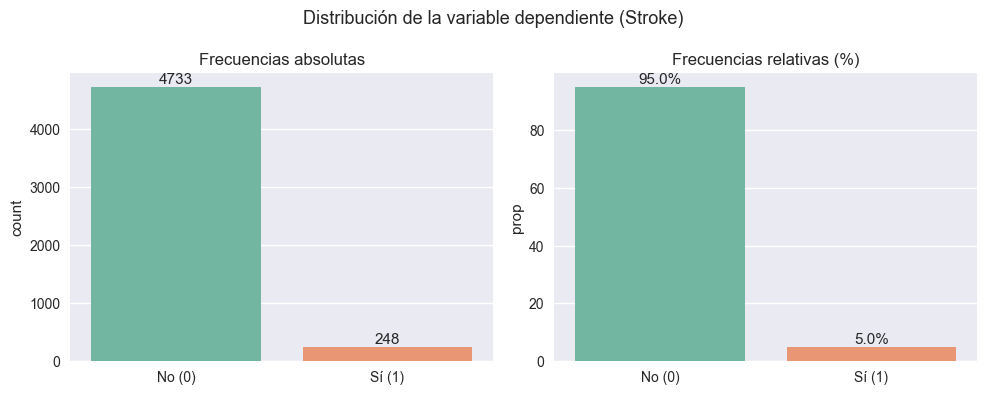

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Distribución de la variable dependiente (Stroke)", fontsize=13)

# Barras de conteo
stroke_counts = df["stroke"].value_counts().reset_index()
stroke_counts.columns = ["stroke", "count"]
stroke_counts["stroke"] = stroke_counts["stroke"].map({0: "No (0)", 1: "Sí (1)"})

sns.barplot(data=stroke_counts, x="stroke", y="count", 
            ax=axes[0], palette="Set2")
axes[0].set_title("Frecuencias absolutas")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

# Barras de proporción
stroke_counts["prop"] = stroke_counts["count"] / stroke_counts["count"].sum() * 100
sns.barplot(data=stroke_counts, x="stroke", y="prop", 
            ax=axes[1], palette="Set2")
axes[1].set_title("Frecuencias relativas (%)")
axes[1].set_xlabel("")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [37]:
from imblearn.over_sampling import SMOTE

# Separar predictores y variable objetivo
X = df.drop(columns="stroke")
y = df["stroke"]

# Codificar variables categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

# Aplicar SMOTE con proporción 80/20
smote = SMOTE(sampling_strategy=0.25, random_state=42)
X_bal, y_bal = smote.fit_resample(X_encoded, y)

# Verificar resultado
print("Dataset original:", df.shape)
print("Dataset balanceado:", X_bal.shape)

print("\nDistribución antes del SMOTE:")
print(y.value_counts())
print(f"Proporción positivos: {y.mean()*100:.1f}%")

print("\nDistribución después del SMOTE:")
print(y_bal.value_counts())
print(f"Proporción positivos: {y_bal.mean()*100:.1f}%")

Dataset original: (4981, 11)
Dataset balanceado: (5916, 14)

Distribución antes del SMOTE:
stroke
0    4733
1     248
Name: count, dtype: int64
Proporción positivos: 5.0%

Distribución después del SMOTE:
stroke
0    4733
1    1183
Name: count, dtype: int64
Proporción positivos: 20.0%


In [38]:
df_bal = X_bal.copy()
df_bal["stroke"] = y_bal.values

# Limpiar nombres de columnas (espacios y guiones causan errores en la fórmula)
df_bal.columns = df_bal.columns.str.replace(" ", "_").str.replace("-", "_")

# Ver columnas disponibles
print(df_bal.columns.tolist())

['age', 'avg_glucose_level', 'bmi', 'gender_Male', 'hypertension_1', 'heart_disease_1', 'ever_married_Yes', 'work_type_Private', 'work_type_Self_employed', 'work_type_children', 'Residence_type_Urban', 'smoking_status_formerly_smoked', 'smoking_status_never_smoked', 'smoking_status_smokes', 'stroke']


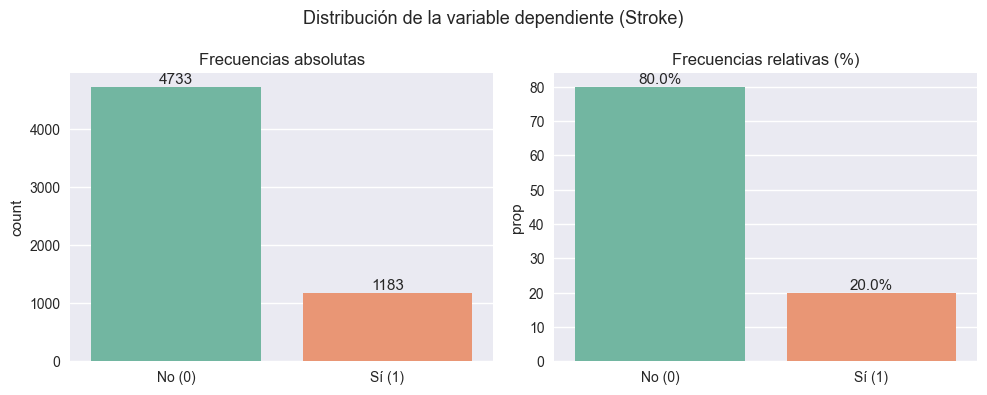

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Distribución de la variable dependiente (Stroke)", fontsize=13)

# Barras de conteo
stroke_counts = df_bal["stroke"].value_counts().reset_index()
stroke_counts.columns = ["stroke", "count"]
stroke_counts["stroke"] = stroke_counts["stroke"].map({0: "No (0)", 1: "Sí (1)"})

sns.barplot(data=stroke_counts, x="stroke", y="count", 
            ax=axes[0], palette="Set2")
axes[0].set_title("Frecuencias absolutas")
axes[0].set_xlabel("")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

# Barras de proporción
stroke_counts["prop"] = stroke_counts["count"] / stroke_counts["count"].sum() * 100
sns.barplot(data=stroke_counts, x="stroke", y="prop", 
            ax=axes[1], palette="Set2")
axes[1].set_title("Frecuencias relativas (%)")
axes[1].set_xlabel("")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 5) Modelo inicial

In [43]:
formula = """stroke ~ age + avg_glucose_level + bmi + gender_Male + hypertension_1 + 
             heart_disease_1 + ever_married_Yes + work_type_Private + 
             work_type_Self_employed + work_type_children + Residence_type_Urban + 
             smoking_status_formerly_smoked + smoking_status_never_smoked + 
             smoking_status_smokes +
             age:avg_glucose_level + age:bmi + avg_glucose_level:bmi +
             hypertension_1:heart_disease_1 + 
             hypertension_1:smoking_status_formerly_smoked +
             heart_disease_1:smoking_status_formerly_smoked +
             hypertension_1:ever_married_Yes +
             gender_Male:heart_disease_1 +
             age:hypertension_1 + age:heart_disease_1 + age:ever_married_Yes +
             avg_glucose_level:hypertension_1 + avg_glucose_level:heart_disease_1"""

modelo = logit(formula, data=df_bal).fit(disp=False)
print(modelo.summary())

                           Logit Regression Results                           
Dep. Variable:                 stroke   No. Observations:                 5916
Model:                          Logit   Df Residuals:                     5888
Method:                           MLE   Df Model:                           27
Date:                Tue, 12 May 2026   Pseudo R-squ.:                  0.4919
Time:                        17:18:45   Log-Likelihood:                -1504.1
converged:                       True   LL-Null:                       -2960.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------------
Intercept                                                        -11.9242      1.509     -7.904      0.000